# Static UMAP Metric Run Script Generator

This notebook is a Delta control panel for the static UMAP metric workflow. It intentionally delegates the real work to the maintained scripts:

1. `static_umap_metric_job_generator.py` creates and submits Slurm job scripts.
2. `static_umap_metrics.py` runs one run/experiment analysis job and writes plots, metric CSVs, summary CSVs, and JSON.

The workflow uses `catalog2.fits` through `catalog-key all`. It does not use separate xmatch catalogs or mmfs paths.

In [1]:
from __future__ import annotations

import shlex
import subprocess
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "static_umap_metric_job_generator.py").exists():
    candidate = NOTEBOOK_DIR / "Hyrax-Research"
    if (candidate / "static_umap_metric_job_generator.py").exists():
        NOTEBOOK_DIR = candidate

GENERATOR = NOTEBOOK_DIR / "static_umap_metric_job_generator.py"
ANALYSIS_SCRIPT = NOTEBOOK_DIR / "static_umap_metrics.py"

if not GENERATOR.exists():
    raise FileNotFoundError(f"Could not find generator script at {GENERATOR}")
if not ANALYSIS_SCRIPT.exists():
    raise FileNotFoundError(f"Could not find analysis script at {ANALYSIS_SCRIPT}")


def run_command(cmd, *, check=True):
    cmd = [str(part) for part in cmd]
    print("$", shlex.join(cmd))
    result = subprocess.run(
        cmd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    if result.stdout:
        print(result.stdout)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}")
    return result

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Generator: {GENERATOR}")
print(f"Analysis script: {ANALYSIS_SCRIPT}")

Notebook directory: /work/hdd/bemi/dmiura/Hyrax-Research
Generator: /work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metric_job_generator.py
Analysis script: /work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metrics.py


## Configure the batch

The defaults below match the current Delta workflow. Leave `RUN_EXPTS` and `OVERLAY_GROUPS` empty to use the generator's built-in notebook plan: Run 10 gets `time_since_merger` plus `future_merger_flags`, and Run 11 gets `time_since_merger`.

In [2]:
PROFILE = "delta"
BASE_DIR = Path("/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs")
# OUTPUT_DIR = BASE_DIR / "static_umap_metrics"
OUTPUT_DIR = BASE_DIR / "static_umap_metrics_tsm_le_1p5gyr"  # For the time_since_merger <= [Whatever number, ex. 1.5] Gyr run

GENERATOR_PYTHON = "python"
JOB_PYTHON = "python"
CATALOG_KEY = "all"
JOB_PREFIX = "plot_metrics_tsm_1p5_"

# Leave empty to use the generator's default Run 10 / Run 11 plan.
# If you add values here, each string should look like "10:7,10,12" or "11:7-14".
RUN_EXPTS = ["10:1-18"] 

# Leave empty to use the generator's per-run defaults. If set, these groups apply to every explicit RUN_EXPTS entry.
OVERLAY_GROUPS = ["time_since_merger"]
N_PERMUTATIONS = 500
MIN_CLUSTER_SIZE = 15
SEED = 42
DPI = 150
TIME_SINCE_MERGER_MAX_GYR = 1.5    # 0.5, 0.75, 1.0, 1.25, 1.5 Gyr
INCLUDE_HIGHDIM = False     # Keep OFF for normal 2D sweeps; HD jobs below override this safely
REQUIRE_HIGHDIM = False     # Use True only with INCLUDE_HIGHDIM; HD notebook jobs default to requiring HD

DENSITY = False
LOG_COLORBAR = False
SHOW_LEGEND = True
SUPPRESS_LOGS = True

# Example: {"partition": "cpu", "mem": "64G", "time": "4:00:00"}
SLURM_OVERRIDES = {}

# None uses the generator defaults. [] removes setup lines. A list replaces setup lines.
SETUP_LINES = None
NO_DEFAULT_SETUP = False


def build_generator_command(action, *, dry_run=False):
    cmd = [
        GENERATOR_PYTHON,
        GENERATOR,
        action,
        "--profile",
        PROFILE,
        "--base-directory",
        BASE_DIR,
        "--output-dir",
        OUTPUT_DIR,
        "--analysis-script",
        ANALYSIS_SCRIPT,
        "--python-executable",
        JOB_PYTHON,
        "--job-prefix",
        JOB_PREFIX,
        "--catalog-key",
        CATALOG_KEY,
        "--n-permutations",
        N_PERMUTATIONS,
        "--min-cluster-size",
        MIN_CLUSTER_SIZE,
        "--seed",
        SEED,
        "--dpi",
        DPI,
    ]

    for spec in RUN_EXPTS:
        cmd.extend(["--run-expts", spec])
    for group in OVERLAY_GROUPS:
        cmd.extend(["--overlay-group", group])
    for key, value in SLURM_OVERRIDES.items():
        cmd.extend(["--slurm", f"{key}={value}"])

    if TIME_SINCE_MERGER_MAX_GYR is not None:
        cmd.extend(["--time-since-merger-max-gyr", TIME_SINCE_MERGER_MAX_GYR])
    if INCLUDE_HIGHDIM:
        cmd.append("--include-highdim")
    if REQUIRE_HIGHDIM:
        cmd.append("--require-highdim")
    if DENSITY:
        cmd.append("--density")
    if LOG_COLORBAR:
        cmd.append("--log-colorbar")
    if not SHOW_LEGEND:
        cmd.append("--no-show-legend")
    if not SUPPRESS_LOGS:
        cmd.append("--no-suppress-logs")

    if SETUP_LINES is not None:
        if len(SETUP_LINES) == 0:
            cmd.append("--no-default-setup")
        else:
            for line in SETUP_LINES:
                cmd.extend(["--setup-line", line])
    elif NO_DEFAULT_SETUP:
        cmd.append("--no-default-setup")

    if dry_run:
        cmd.append("--dry-run")
    return cmd

print(f"Profile: {PROFILE}")
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Catalog key: {CATALOG_KEY}")


Profile: delta
Base directory: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs
Output directory: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr
Catalog key: all


## Preview the plan

Run this before creating scripts. It prints the runs, experiments, overlay groups, Slurm settings, catalog key, and output path.

In [ ]:
run_command(build_generator_command("print-plan"))

## Generate Slurm scripts

This writes `plot_metrics<run>_<expt>.sh` into each selected `run<run>/` directory. It does not submit anything.

In [ ]:
run_command(build_generator_command("write"))

## Dry-run submission

This checks the generated scripts and prints the exact `sbatch` commands without submitting jobs.

In [ ]:
run_command(build_generator_command("submit-existing", dry_run=True))

## Submit existing scripts

The guard below prevents accidental submissions. Set `SUBMIT_JOBS = True` only after the dry-run output looks correct.

In [ ]:
SUBMIT_JOBS = False

if SUBMIT_JOBS:
    run_command(build_generator_command("submit-existing"))
else:
    print("SUBMIT_JOBS is False; no jobs submitted.")


## View multi-cutoff results

This section scans cutoff-specific output folders under `BASE_DIR`, combines every metrics CSV for a chosen run, ranks the strongest run/expt/cutoff/overlay rows, and displays summary tables plus optional PNGs. It can scan both the original 2D result folders and HD result folders ending in `_hd`.

Change `RANKING_MODE` to switch the sort logic:

- `mnln_p`: lowest 2D MNLN p-value, then lowest 2D MNLN ratio.
- `mnln_effect`: lowest 2D MNLN ratio, then lowest 2D MNLN p-value.
- `cmc_p`: lowest 2D CMC-Gini p-value, then highest 2D CMC-Gini.
- `cmc_effect`: highest 2D CMC-Gini z-score, then lowest 2D CMC-Gini p-value.
- `composite`: average rank across 2D MNLN p-value, 2D MNLN ratio, 2D CMC p-value, and 2D CMC z-score.
- `stable_cutoff`: groups by result family, run, experiment, and overlay, then ranks cases that stay strong across multiple cutoffs.
- `mnln_hd_p`, `mnln_hd_effect`, `cmc_hd_p`, `cmc_hd_effect`, `hd_composite`: HD equivalents, only meaningful for rows with HD metrics.
- `2d_hd_agreement`: ranks rows that are strong in both 2D and HD metrics.

Metric reminder: p-values are not the probability that clusters exist. Lower p-values mean a random same-sized selected set would less often look at least this clustered by that metric. For MNLN, ratios below 1 mean selected points are closer together than random. For CMC-Gini, higher Gini/z-score means selected labels concentrate more strongly in HDBSCAN regions.


In [5]:
import math
import re

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


RESULT_RUN = 10 # TODO
RESULT_CUTOFFS = [0.5, 0.75, 1.0, 1.25, 1.5] # TODO
RESULT_FAMILIES = ["hd"]       # TODO: Use ["2d"] for original results only or ["hd"] for HD-only viewing.
# RESULT_FAMILIES = ["2d", "hd"]
RESULT_OUTPUT_GLOB = "static_umap_metrics_tsm_le_*gyr"  # Kept for custom/single-family scans.
RESULT_OUTPUT_GLOBS = {
    "2d": "static_umap_metrics_tsm_le_*gyr",
    "hd": "static_umap_metrics_tsm_le_*gyr_hd",
}
RANKING_MODE = "mnln_hd_effect" # TODO: Remember to adjust this
TOP_N = 20

# Optional filters. Leave as None to include everything found.
RESULT_EXPTS = None                 # Example: [1, 5, 8, 12]
RESULT_OVERLAY_GROUPS = None        # Example: ["time_since_merger"]
RESULT_OVERLAY_KEYS = None          # Example: ["Major_TimeSinceMerger"]
RESULT_OVERLAY_LABEL_CONTAINS = None
MIN_MATCHED = 2

PIVOT_VALUE = "mnln_2d_p_value"
SHOW_TOP_PNGS = True
MAX_GALLERY_IMAGES = 8

STABLE_P_VALUE_MAX = 0.05
STABLE_RATIO_MAX = 1.0
STABLE_MIN_CUTOFFS = 2

HD_REQUIRED_RESULT_COLUMNS = ["mnln_hd_p_value", "mnln_hd_ratio", "cmc_hd_p_value", "cmc_hd_z_score"]

TOP_RESULT_COLUMNS = [
    "result_family",
    "has_highdim_metrics",
    "run",
    "expt",
    "cutoff_gyr",
    "overlay_label",
    "overlay_key",
    "n_matched",
    "mnln_2d_p_value",
    "mnln_2d_ratio",
    "mnln_2d_observed",
    "mnln_2d_expected",
    "cmc_2d_p_value",
    "cmc_2d_gini",
    "cmc_2d_expected_gini",
    "cmc_2d_z_score",
    "cmc_2d_n_clusters",
    "mnln_hd_p_value",
    "mnln_hd_ratio",
    "mnln_hd_observed",
    "mnln_hd_expected",
    "mnln_hd_z_score",
    "cmc_hd_p_value",
    "cmc_hd_gini",
    "cmc_hd_expected_gini",
    "cmc_hd_z_score",
    "cmc_hd_n_clusters",
    "png_path",
]

STABLE_RESULT_COLUMNS = [
    "result_family",
    "has_highdim_metrics",
    "run",
    "expt",
    "overlay_label",
    "overlay_key",
    "n_cutoffs",
    "cutoffs_seen",
    "n_mnln_p_le_threshold",
    "n_mnln_ratio_lt_threshold",
    "median_mnln_2d_p_value",
    "median_mnln_2d_ratio",
    "best_mnln_2d_p_value",
    "best_mnln_2d_ratio",
    "best_cutoff_gyr",
    "best_cmc_2d_p_value",
    "best_cmc_2d_z_score",
    "best_mnln_hd_p_value",
    "best_mnln_hd_ratio",
    "best_cmc_hd_p_value",
    "best_cmc_hd_z_score",
    "png_path",
]

NUMERIC_RESULT_COLUMNS = [
    "run",
    "expt",
    "cutoff_gyr",
    "n_matched",
    "mnln_2d_p_value",
    "mnln_2d_ratio",
    "mnln_2d_observed",
    "mnln_2d_expected",
    "mnln_2d_z_score",
    "cmc_2d_p_value",
    "cmc_2d_gini",
    "cmc_2d_expected_gini",
    "cmc_2d_z_score",
    "cmc_2d_n_clusters",
    "mnln_hd_p_value",
    "mnln_hd_ratio",
    "mnln_hd_observed",
    "mnln_hd_expected",
    "mnln_hd_z_score",
    "cmc_hd_p_value",
    "cmc_hd_gini",
    "cmc_hd_expected_gini",
    "cmc_hd_z_score",
    "cmc_hd_n_clusters",
]

RANKING_DESCRIPTIONS = {
    "mnln_p": "Lowest 2D MNLN p-value, then lowest 2D MNLN ratio.",
    "mnln_effect": "Lowest 2D MNLN ratio, then lowest 2D MNLN p-value.",
    "cmc_p": "Lowest 2D CMC-Gini p-value, then highest 2D CMC-Gini.",
    "cmc_effect": "Highest 2D CMC-Gini z-score, then lowest 2D CMC-Gini p-value.",
    "composite": "Average rank across 2D MNLN p-value, 2D MNLN ratio, 2D CMC p-value, and 2D CMC z-score.",
    "stable_cutoff": "Groups by result family, run, experiment, and overlay, then ranks cases that stay strong across cutoffs.",
    "mnln_hd_p": "Lowest HD MNLN p-value, then lowest HD MNLN ratio.",
    "mnln_hd_effect": "Lowest HD MNLN ratio, then lowest HD MNLN p-value.",
    "cmc_hd_p": "Lowest HD CMC-Gini p-value, then highest HD CMC-Gini.",
    "cmc_hd_effect": "Highest HD CMC-Gini z-score, then lowest HD CMC-Gini p-value.",
    "hd_composite": "Average rank across HD MNLN p-value, HD MNLN ratio, HD CMC p-value, and HD CMC z-score.",
    "2d_hd_agreement": "Average rank across 2D and HD MNLN/CMC evidence; rows missing HD rank last.",
}


def parse_run_expt_from_path(path):
    path = Path(path)
    run = None
    expt = None
    for part in path.parts:
        run_match = re.fullmatch(r"run(\d+)", part)
        expt_match = re.fullmatch(r"expt(\d+)", part)
        if run_match:
            run = int(run_match.group(1))
        if expt_match:
            expt = int(expt_match.group(1))
    return run, expt


def parse_cutoff_from_name(name):
    match = re.search(r"tsm_le_([0-9]+(?:[p.][0-9]+)?)gyr", str(name))
    if not match:
        return math.nan
    return float(match.group(1).replace("p", "."))


def infer_result_family(path):
    name = Path(path).name
    return "hd" if name.endswith("_hd") else "2d"


def cutoff_is_requested(cutoff, requested_cutoffs):
    if requested_cutoffs is None or len(requested_cutoffs) == 0:
        return True
    if pd.isna(cutoff):
        return False
    return any(math.isclose(float(cutoff), float(requested), rel_tol=0, abs_tol=1e-9) for requested in requested_cutoffs)


def iter_result_glob_requests(output_glob=RESULT_OUTPUT_GLOB, output_globs=RESULT_OUTPUT_GLOBS, families=RESULT_FAMILIES):
    if output_globs is None:
        yield "custom", output_glob
        return
    requested = families if families is not None else list(output_globs)
    for family in requested:
        if family not in output_globs:
            raise ValueError(f"Unknown result family {family!r}. Options: {sorted(output_globs)}")
        yield family, output_globs[family]


def discover_result_roots(
    base_dir=BASE_DIR,
    output_glob=RESULT_OUTPUT_GLOB,
    cutoffs=RESULT_CUTOFFS,
    result_families=RESULT_FAMILIES,
    output_globs=RESULT_OUTPUT_GLOBS,
):
    base_dir = Path(base_dir)
    roots = []
    seen = set()
    for family, glob_pattern in iter_result_glob_requests(output_glob=output_glob, output_globs=output_globs, families=result_families):
        for root in sorted(base_dir.glob(glob_pattern)):
            if not root.is_dir():
                continue
            root_key = str(root)
            if root_key in seen:
                continue
            seen.add(root_key)
            cutoff = parse_cutoff_from_name(root.name)
            if not cutoff_is_requested(cutoff, cutoffs):
                continue
            roots.append({
                "result_root": root,
                "cutoff_gyr": cutoff,
                "result_family": infer_result_family(root) if family == "custom" else family,
            })
    return sorted(roots, key=lambda item: (item["result_family"], pd.isna(item["cutoff_gyr"]), item["cutoff_gyr"], str(item["result_root"])))


def discover_result_dirs(
    base_dir=BASE_DIR,
    output_glob=RESULT_OUTPUT_GLOB,
    cutoffs=RESULT_CUTOFFS,
    run=RESULT_RUN,
    expts=RESULT_EXPTS,
    result_families=RESULT_FAMILIES,
    output_globs=RESULT_OUTPUT_GLOBS,
):
    expt_filter = None if expts is None else {int(expt) for expt in expts}
    rows = []
    for root_info in discover_result_roots(
        base_dir=base_dir,
        output_glob=output_glob,
        cutoffs=cutoffs,
        result_families=result_families,
        output_globs=output_globs,
    ):
        root = root_info["result_root"]
        if run is None:
            candidates = sorted(root.glob("run*/expt*"))
        else:
            candidates = sorted((root / f"run{int(run)}").glob("expt*"))
        for result_dir in candidates:
            if not result_dir.is_dir():
                continue
            parsed_run, parsed_expt = parse_run_expt_from_path(result_dir)
            if expt_filter is not None and parsed_expt not in expt_filter:
                continue
            rows.append({
                "result_root": root,
                "result_dir": result_dir,
                "cutoff_gyr": root_info["cutoff_gyr"],
                "result_family": root_info["result_family"],
                "run": parsed_run,
                "expt": parsed_expt,
            })
    return rows


def make_png_path(row):
    overlay_group = row.get("overlay_group")
    run = row.get("run")
    expt = row.get("expt")
    result_dir = Path(row.get("result_dir"))
    if pd.isna(overlay_group) or pd.isna(run) or pd.isna(expt):
        return ""
    return str(result_dir / f"run{int(run)}_expt{int(expt)}_{overlay_group}.png")


def coerce_result_columns(frame):
    frame = frame.copy()
    for column in NUMERIC_RESULT_COLUMNS:
        if column not in frame.columns:
            frame[column] = pd.NA
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def load_multicutoff_csvs(
    pattern,
    base_dir=BASE_DIR,
    output_glob=RESULT_OUTPUT_GLOB,
    cutoffs=RESULT_CUTOFFS,
    run=RESULT_RUN,
    expts=RESULT_EXPTS,
    result_families=RESULT_FAMILIES,
    output_globs=RESULT_OUTPUT_GLOBS,
):
    frames = []
    result_dirs = discover_result_dirs(
        base_dir=base_dir,
        output_glob=output_glob,
        cutoffs=cutoffs,
        run=run,
        expts=expts,
        result_families=result_families,
        output_globs=output_globs,
    )
    for info in result_dirs:
        for path in sorted(info["result_dir"].glob(pattern)):
            frame = pd.read_csv(path)
            frame["source_file"] = str(path)
            frame["result_root"] = str(info["result_root"])
            frame["result_dir"] = str(info["result_dir"])
            frame["result_family"] = info["result_family"]
            frame["cutoff_gyr"] = info["cutoff_gyr"]
            if "run" not in frame.columns or frame["run"].isna().all():
                frame["run"] = info["run"]
            if "expt" not in frame.columns or frame["expt"].isna().all():
                frame["expt"] = info["expt"]
            frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def load_multicutoff_metric_results(**kwargs):
    frame = load_multicutoff_csvs("*_metrics.csv", **kwargs)
    if frame.empty:
        return frame
    frame = coerce_result_columns(frame)
    frame["png_path"] = frame.apply(make_png_path, axis=1)
    frame["png_exists"] = frame["png_path"].map(lambda item: Path(item).exists() if item else False)
    frame["has_highdim_metrics"] = frame[HD_REQUIRED_RESULT_COLUMNS].notna().all(axis=1)
    return frame


def load_multicutoff_overlay_summary(**kwargs):
    frame = load_multicutoff_csvs("*_overlay_summary.csv", **kwargs)
    if frame.empty:
        return frame
    return coerce_result_columns(frame)


def filter_metric_results(
    frame,
    expts=RESULT_EXPTS,
    overlay_groups=RESULT_OVERLAY_GROUPS,
    overlay_keys=RESULT_OVERLAY_KEYS,
    overlay_label_contains=RESULT_OVERLAY_LABEL_CONTAINS,
    min_matched=MIN_MATCHED,
):
    if frame.empty:
        return frame.copy()
    work = frame.copy()
    if expts is not None:
        work = work[work["expt"].isin([int(expt) for expt in expts])]
    if overlay_groups is not None and "overlay_group" in work.columns:
        work = work[work["overlay_group"].isin(overlay_groups)]
    if overlay_keys is not None and "overlay_key" in work.columns:
        work = work[work["overlay_key"].isin(overlay_keys)]
    if overlay_label_contains:
        work = work[work["overlay_label"].astype(str).str.contains(overlay_label_contains, case=False, na=False)]
    if min_matched is not None and "n_matched" in work.columns:
        work = work[work["n_matched"] >= int(min_matched)]
    return work.reset_index(drop=True)


def add_rank_columns(work, rank_specs, score_column):
    rank_columns = []
    for column, ascending in rank_specs:
        rank_column = f"rank_{column}"
        work[rank_column] = work[column].rank(ascending=ascending, na_option="bottom", method="min")
        rank_columns.append(rank_column)
    work[score_column] = work[rank_columns].mean(axis=1)
    return work


def sort_job_level_results(frame, mode):
    work = frame.copy()
    if mode == "mnln_p":
        return work.sort_values(["mnln_2d_p_value", "mnln_2d_ratio"], ascending=[True, True], na_position="last")
    if mode == "mnln_effect":
        return work.sort_values(["mnln_2d_ratio", "mnln_2d_p_value"], ascending=[True, True], na_position="last")
    if mode == "cmc_p":
        return work.sort_values(["cmc_2d_p_value", "cmc_2d_gini"], ascending=[True, False], na_position="last")
    if mode == "cmc_effect":
        return work.sort_values(["cmc_2d_z_score", "cmc_2d_p_value"], ascending=[False, True], na_position="last")
    if mode == "mnln_hd_p":
        return work.sort_values(["mnln_hd_p_value", "mnln_hd_ratio"], ascending=[True, True], na_position="last")
    if mode == "mnln_hd_effect":
        return work.sort_values(["mnln_hd_ratio", "mnln_hd_p_value"], ascending=[True, True], na_position="last")
    if mode == "cmc_hd_p":
        return work.sort_values(["cmc_hd_p_value", "cmc_hd_gini"], ascending=[True, False], na_position="last")
    if mode == "cmc_hd_effect":
        return work.sort_values(["cmc_hd_z_score", "cmc_hd_p_value"], ascending=[False, True], na_position="last")
    if mode == "composite":
        work = add_rank_columns(
            work,
            [
                ("mnln_2d_p_value", True),
                ("mnln_2d_ratio", True),
                ("cmc_2d_p_value", True),
                ("cmc_2d_z_score", False),
            ],
            "composite_rank_score",
        )
        return work.sort_values(["composite_rank_score", "mnln_2d_p_value", "mnln_2d_ratio"], ascending=[True, True, True], na_position="last")
    if mode == "hd_composite":
        work = add_rank_columns(
            work,
            [
                ("mnln_hd_p_value", True),
                ("mnln_hd_ratio", True),
                ("cmc_hd_p_value", True),
                ("cmc_hd_z_score", False),
            ],
            "hd_composite_rank_score",
        )
        return work.sort_values(["hd_composite_rank_score", "mnln_hd_p_value", "mnln_hd_ratio"], ascending=[True, True, True], na_position="last")
    if mode == "2d_hd_agreement":
        work = add_rank_columns(
            work,
            [
                ("mnln_2d_p_value", True),
                ("mnln_2d_ratio", True),
                ("cmc_2d_p_value", True),
                ("cmc_2d_z_score", False),
                ("mnln_hd_p_value", True),
                ("mnln_hd_ratio", True),
                ("cmc_hd_p_value", True),
                ("cmc_hd_z_score", False),
            ],
            "agreement_rank_score",
        )
        return work.sort_values(["agreement_rank_score", "mnln_hd_p_value", "mnln_2d_p_value"], ascending=[True, True, True], na_position="last")
    raise ValueError(f"Unknown RANKING_MODE {mode!r}. Options: {', '.join(RANKING_DESCRIPTIONS)}")


def format_cutoff_list(values):
    clean = [float(value) for value in values if not pd.isna(value)]
    return ", ".join(f"{value:g}" for value in sorted(set(clean)))


def rank_stable_cutoff_results(frame):
    if frame.empty:
        return frame.copy()
    rows = []
    group_cols = ["result_family", "run", "expt", "overlay_group", "overlay_key"]
    for keys, group in frame.groupby(group_cols, dropna=False):
        n_cutoffs = int(group["cutoff_gyr"].nunique(dropna=True))
        if STABLE_MIN_CUTOFFS is not None and n_cutoffs < int(STABLE_MIN_CUTOFFS):
            continue
        best = sort_job_level_results(group, "mnln_p").iloc[0]
        row = dict(zip(group_cols, keys))
        row.update({
            "overlay_label": best.get("overlay_label"),
            "has_highdim_metrics": bool(group.get("has_highdim_metrics", pd.Series(False, index=group.index)).any()),
            "n_cutoffs": n_cutoffs,
            "cutoffs_seen": format_cutoff_list(group["cutoff_gyr"]),
            "n_mnln_p_le_threshold": int((group["mnln_2d_p_value"] <= STABLE_P_VALUE_MAX).sum()),
            "n_mnln_ratio_lt_threshold": int((group["mnln_2d_ratio"] < STABLE_RATIO_MAX).sum()),
            "median_mnln_2d_p_value": group["mnln_2d_p_value"].median(),
            "median_mnln_2d_ratio": group["mnln_2d_ratio"].median(),
            "best_mnln_2d_p_value": group["mnln_2d_p_value"].min(),
            "best_mnln_2d_ratio": group["mnln_2d_ratio"].min(),
            "best_cutoff_gyr": best.get("cutoff_gyr"),
            "best_cmc_2d_p_value": group["cmc_2d_p_value"].min(),
            "best_cmc_2d_z_score": group["cmc_2d_z_score"].max(),
            "best_mnln_hd_p_value": group["mnln_hd_p_value"].min(),
            "best_mnln_hd_ratio": group["mnln_hd_ratio"].min(),
            "best_cmc_hd_p_value": group["cmc_hd_p_value"].min(),
            "best_cmc_hd_z_score": group["cmc_hd_z_score"].max(),
            "n_matched": best.get("n_matched"),
            "mnln_2d_p_value": best.get("mnln_2d_p_value"),
            "mnln_2d_ratio": best.get("mnln_2d_ratio"),
            "cmc_2d_p_value": best.get("cmc_2d_p_value"),
            "cmc_2d_gini": best.get("cmc_2d_gini"),
            "cmc_2d_z_score": best.get("cmc_2d_z_score"),
            "mnln_hd_p_value": best.get("mnln_hd_p_value"),
            "mnln_hd_ratio": best.get("mnln_hd_ratio"),
            "cmc_hd_p_value": best.get("cmc_hd_p_value"),
            "cmc_hd_gini": best.get("cmc_hd_gini"),
            "cmc_hd_z_score": best.get("cmc_hd_z_score"),
            "result_dir": best.get("result_dir"),
            "source_file": best.get("source_file"),
            "png_path": best.get("png_path"),
            "png_exists": best.get("png_exists", False),
        })
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    stable = pd.DataFrame(rows)
    return stable.sort_values(
        [
            "n_mnln_p_le_threshold",
            "n_mnln_ratio_lt_threshold",
            "median_mnln_2d_p_value",
            "median_mnln_2d_ratio",
            "best_mnln_2d_p_value",
        ],
        ascending=[False, False, True, True, True],
        na_position="last",
    ).reset_index(drop=True)


def rank_metric_results(frame, mode=RANKING_MODE):
    if frame.empty:
        return frame.copy()
    if mode == "stable_cutoff":
        ranked = rank_stable_cutoff_results(frame)
    else:
        ranked = sort_job_level_results(frame, mode).reset_index(drop=True)
    if not ranked.empty:
        ranked.insert(0, "rank", range(1, len(ranked) + 1))
    return ranked


def select_columns(frame, columns):
    available = [column for column in columns if column in frame.columns]
    return frame.loc[:, available]


def display_table(title, frame, columns=None, max_rows=TOP_N):
    display(Markdown(f"### {title}"))
    if frame.empty:
        print("No rows found.")
        return
    shown = frame if max_rows is None else frame.head(max_rows)
    if columns is not None:
        shown = select_columns(shown, ["rank"] + columns if "rank" in shown.columns and "rank" not in columns else columns)
    display(shown)


def best_per_group(frame, group_cols, mode=RANKING_MODE):
    if frame.empty:
        return frame.copy()
    ranked = sort_job_level_results(frame, "mnln_p" if mode == "stable_cutoff" else mode).copy()
    return ranked.groupby(group_cols, dropna=False, as_index=False).head(1).reset_index(drop=True)


def make_cutoff_expt_pivot(frame, value=PIVOT_VALUE):
    if frame.empty or value not in frame.columns:
        return pd.DataFrame()
    return frame.pivot_table(index="expt", columns="cutoff_gyr", values=value, aggfunc="min").sort_index()


def display_highdim_coverage(frame):
    display(Markdown("### High-dimensional coverage"))
    if frame.empty:
        print("No metric rows found.")
        return
    total = len(frame)
    hd_rows = int(frame.get("has_highdim_metrics", pd.Series(False, index=frame.index)).sum())
    print(f"Rows with HD metrics: {hd_rows} of {total}")
    if "result_family" in frame.columns:
        family_counts = frame.groupby("result_family")["has_highdim_metrics"].agg(rows="size", rows_with_hd="sum").reset_index()
        display(family_counts)
        hd_family = frame[frame["result_family"].eq("hd")]
        missing_dirs = sorted(hd_family.loc[~hd_family["has_highdim_metrics"], "result_dir"].dropna().astype(str).unique())
        if missing_dirs:
            print("HD result folders with CSV rows but missing HD metric columns:")
            for path in missing_dirs[:20]:
                print(f"  {path}")
            if len(missing_dirs) > 20:
                print(f"  ... {len(missing_dirs) - 20} more")


def display_png_gallery(frame, max_images=MAX_GALLERY_IMAGES):
    if frame.empty or max_images == 0:
        return
    png_rows = frame[frame.get("png_path", "").astype(str).map(lambda item: bool(item) and Path(item).exists())]
    if png_rows.empty:
        print("No PNG files found for the displayed top rows.")
        return
    display(Markdown(f"### Top PNGs ({min(len(png_rows), max_images)} of {len(png_rows)})"))
    for _, row in png_rows.head(max_images).iterrows():
        cutoff = row.get("cutoff_gyr", math.nan)
        if pd.isna(cutoff):
            cutoff = row.get("best_cutoff_gyr", math.nan)
        title = (
            f"{row.get('result_family', 'result')} | Run {int(row['run'])}, Expt {int(row['expt'])}, cutoff {cutoff:g} Gyr, "
            f"{row.get('overlay_label', row.get('overlay_key', 'overlay'))}"
        )
        metric_text = (
            f"2D MNLN p={row.get('mnln_2d_p_value', math.nan):.4g}, "
            f"2D ratio={row.get('mnln_2d_ratio', math.nan):.4g}, "
            f"HD MNLN p={row.get('mnln_hd_p_value', math.nan):.4g}, "
            f"HD ratio={row.get('mnln_hd_ratio', math.nan):.4g}"
        )
        display(Markdown(f"**{title}**  \\\n{metric_text}"))
        display(Image(filename=str(row["png_path"])))


def display_multicutoff_results(
    run=RESULT_RUN,
    cutoffs=RESULT_CUTOFFS,
    output_glob=RESULT_OUTPUT_GLOB,
    output_globs=RESULT_OUTPUT_GLOBS,
    result_families=RESULT_FAMILIES,
    mode=RANKING_MODE,
    top_n=TOP_N,
):
    print(f"Base directory: {Path(BASE_DIR)}")
    print(f"Result families: {result_families}")
    print(f"Run filter: {run}")
    print(f"Cutoff filter: {cutoffs}")
    print(f"Ranking mode: {mode} - {RANKING_DESCRIPTIONS.get(mode, 'custom')}")

    roots = discover_result_roots(base_dir=BASE_DIR, output_glob=output_glob, output_globs=output_globs, cutoffs=cutoffs, result_families=result_families)
    if roots:
        print("Result roots found:")
        for root in roots:
            print(f"  family={root['result_family']} cutoff={root['cutoff_gyr']:g}: {root['result_root']}")
    else:
        print("No matching result roots found.")

    metrics = load_multicutoff_metric_results(
        base_dir=BASE_DIR,
        output_glob=output_glob,
        output_globs=output_globs,
        cutoffs=cutoffs,
        run=run,
        expts=RESULT_EXPTS,
        result_families=result_families,
    )
    metrics = filter_metric_results(metrics)
    if metrics.empty:
        print("No metrics CSV rows found after filters.")
        return metrics, pd.DataFrame()

    print(f"Metric rows after filters: {len(metrics)}")
    print(f"Experiments found: {sorted(metrics['expt'].dropna().astype(int).unique())}")
    print(f"Cutoffs found: {format_cutoff_list(metrics['cutoff_gyr'])}")
    display_highdim_coverage(metrics)

    ranked = rank_metric_results(metrics, mode=mode)
    table_columns = STABLE_RESULT_COLUMNS if mode == "stable_cutoff" else TOP_RESULT_COLUMNS
    display_table("Top Results", ranked, columns=table_columns, max_rows=top_n)

    best_expt = best_per_group(metrics, ["run", "expt"], mode=mode)
    display_table("Best Result Per Experiment", rank_metric_results(best_expt, "mnln_p" if mode == "stable_cutoff" else mode), columns=TOP_RESULT_COLUMNS, max_rows=None)

    best_cutoff = best_per_group(metrics, ["run", "cutoff_gyr"], mode=mode)
    display_table("Best Result Per Cutoff", rank_metric_results(best_cutoff, "mnln_p" if mode == "stable_cutoff" else mode), columns=TOP_RESULT_COLUMNS, max_rows=None)

    pivot = make_cutoff_expt_pivot(metrics, value=PIVOT_VALUE)
    display(Markdown(f"### Cutoff by Experiment Pivot: `{PIVOT_VALUE}`"))
    if pivot.empty:
        print(f"Cannot build pivot because `{PIVOT_VALUE}` is unavailable.")
    else:
        display(pivot)

    if SHOW_TOP_PNGS:
        display_png_gallery(ranked, max_images=MAX_GALLERY_IMAGES)

    return metrics, ranked


Base directory: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs
Result families: ['hd']
Run filter: 10
Cutoff filter: [0.5, 0.75, 1.0, 1.25, 1.5]
Ranking mode: mnln_hd_effect - Lowest HD MNLN ratio, then lowest HD MNLN p-value.
Result roots found:
  family=hd cutoff=0.5: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd
  family=hd cutoff=0.75: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd
  family=hd cutoff=1: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd
  family=hd cutoff=1.25: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p25gyr_hd
  family=hd cutoff=1.5: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd
Metric rows after filters: 54
Experiments found: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.in

### High-dimensional coverage

Rows with HD metrics: 33 of 54


,result_family,rows,rows_with_hd
0,hd,54,33


HD result folders with CSV rows but missing HD metric columns:
  /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt13
  /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt13
  /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt16
  /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt14
  /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p25gyr_hd/run10/expt10
  /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd/run10/expt11
  /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd/run10/expt13


...

,rank,result_family,has_highdim_metrics,run,expt,cutoff_gyr,overlay_label,overlay_key,n_matched,mnln_2d_p_value,mnln_2d_ratio,mnln_2d_observed,mnln_2d_expected,cmc_2d_p_value,cmc_2d_gini,cmc_2d_expected_gini,cmc_2d_z_score,cmc_2d_n_clusters,mnln_hd_p_value,mnln_hd_ratio,mnln_hd_observed,mnln_hd_expected,mnln_hd_z_score,cmc_hd_p_value,cmc_hd_gini,cmc_hd_expected_gini,cmc_hd_z_score,cmc_hd_n_clusters,png_path
0,1,hd,False,10,11,1.50,Mini time since <= 1.5 Gyr,Mini_TimeSinceMerger,1993,0.095808,0.972555,0.056120,0.057704,0.117764,0.788775,0.779913,1.185699,35,1.0,1.114250,0.000027,0.000024,14.731090,NaN,NaN,NaN,NaN,0,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd/run10/expt11/run10_expt11_time_since_merger.png
1,2,hd,False,10,10,1.25,Mini time since <= 1.25 Gyr,Mini_TimeSinceMerger,1710,0.053892,0.964397,0.062158,0.064453,0.025948,0.819476,0.806598,1.948856,22,1.0,1.129775,0.000026,0.000023,12.856204,NaN,NaN,NaN,NaN,0,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p25gyr_hd/run10/expt10/run10_expt10_time_since_merger.png
2,3,hd,False,10,14,1.00,Mini time since <= 1 Gyr,Mini_TimeSinceMerger,1553,0.005988,0.936033,0.064554,0.068965,0.514970,0.776494,0.776572,-0.011670,18,1.0,1.154907,0.000065,0.000056,14.484365,NaN,NaN,NaN,NaN,0,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt14/run10_expt14_time_since_merger.png
3,4,hd,False,10,13,0.75,Minor time since <= 0.75 Gyr,Minor_TimeSinceMerger,208,0.007984,0.843649,0.167549,0.198600,0.840319,0.641026,0.647513,-0.751000,2,1.0,1.161859,0.000053,0.000046,4.140182,NaN,NaN,NaN,NaN,0,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt13/run10_expt13_time_since_merger.png
4,5,hd,False,10,13,0.50,Minor time since <= 0.5 Gyr,Minor_TimeSinceMerger,170,0.001996,0.780955,0.171351,0.219413,0.840319,0.639216,0.646800,-0.769204,2,1.0,1.163792,0.000054,0.000046,3.619846,NaN,NaN,NaN,NaN,0,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt13/run10_expt13_time_since_merger.png


### Cutoff by Experiment Pivot: `mnln_2d_p_value`

cutoff_gyr,0.50,0.75,1.00,1.25,1.50
expt,,,,,
5,NaN,NaN,0.009980,0.001996,0.001996
6,0.007984,0.005988,NaN,NaN,NaN
7,NaN,0.001996,0.005988,NaN,NaN
8,0.003992,NaN,0.009980,0.003992,0.001996
10,NaN,NaN,NaN,0.007984,NaN
11,NaN,NaN,NaN,NaN,0.005988
13,0.001996,0.007984,NaN,NaN,0.003992
14,NaN,NaN,0.005988,NaN,NaN
16,NaN,0.009980,NaN,NaN,NaN


### Top PNGs (8 of 54)

**hd | Run 10, Expt 11, cutoff 1.5 Gyr, Mini time since <= 1.5 Gyr**  \
2D MNLN p=0.09581, 2D ratio=0.9726, HD MNLN p=1, HD ratio=1.114

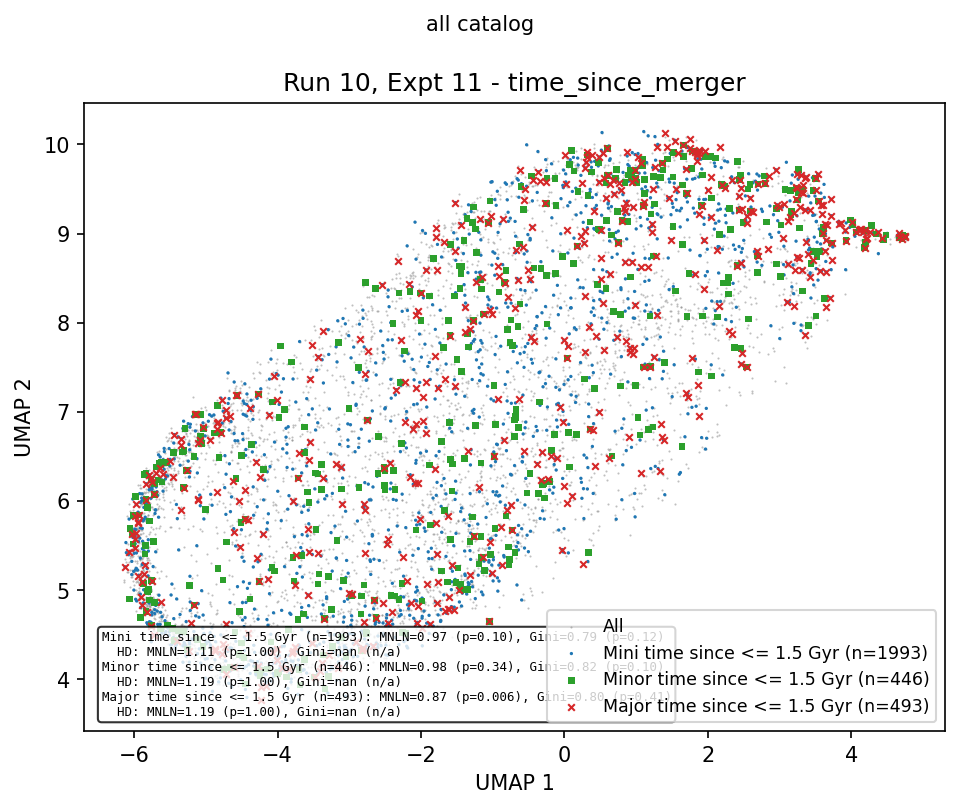

**hd | Run 10, Expt 10, cutoff 1.25 Gyr, Mini time since <= 1.25 Gyr**  \
2D MNLN p=0.05389, 2D ratio=0.9644, HD MNLN p=1, HD ratio=1.13

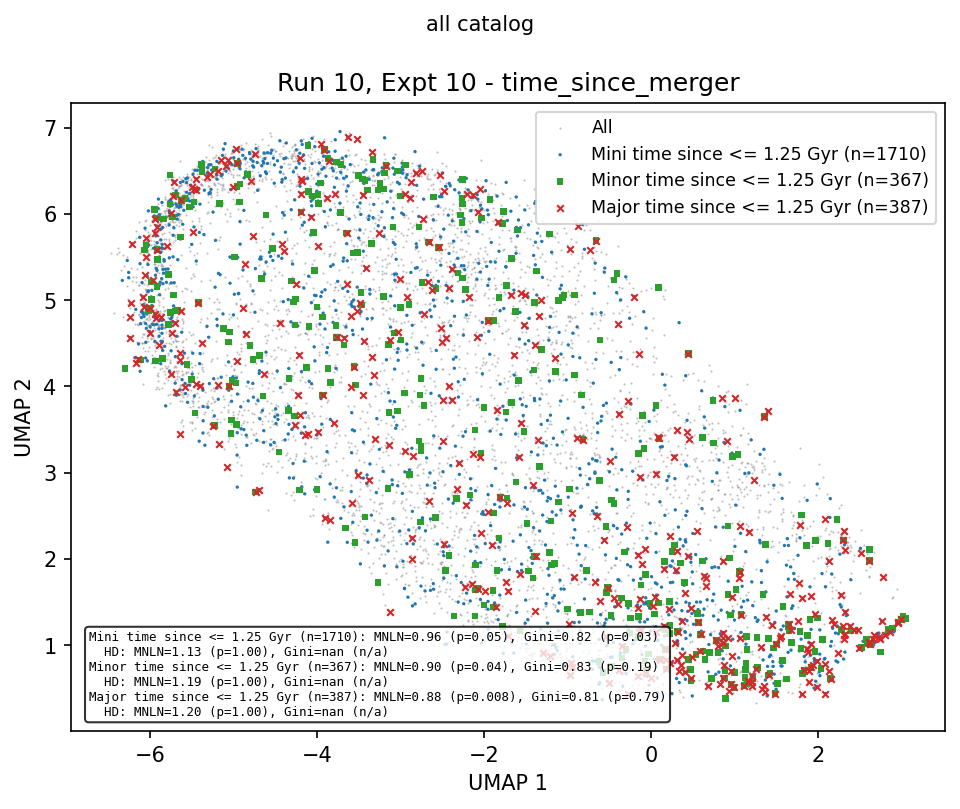

**hd | Run 10, Expt 13, cutoff 1.5 Gyr, Mini time since <= 1.5 Gyr**  \
2D MNLN p=0.1337, 2D ratio=0.9771, HD MNLN p=1, HD ratio=1.146

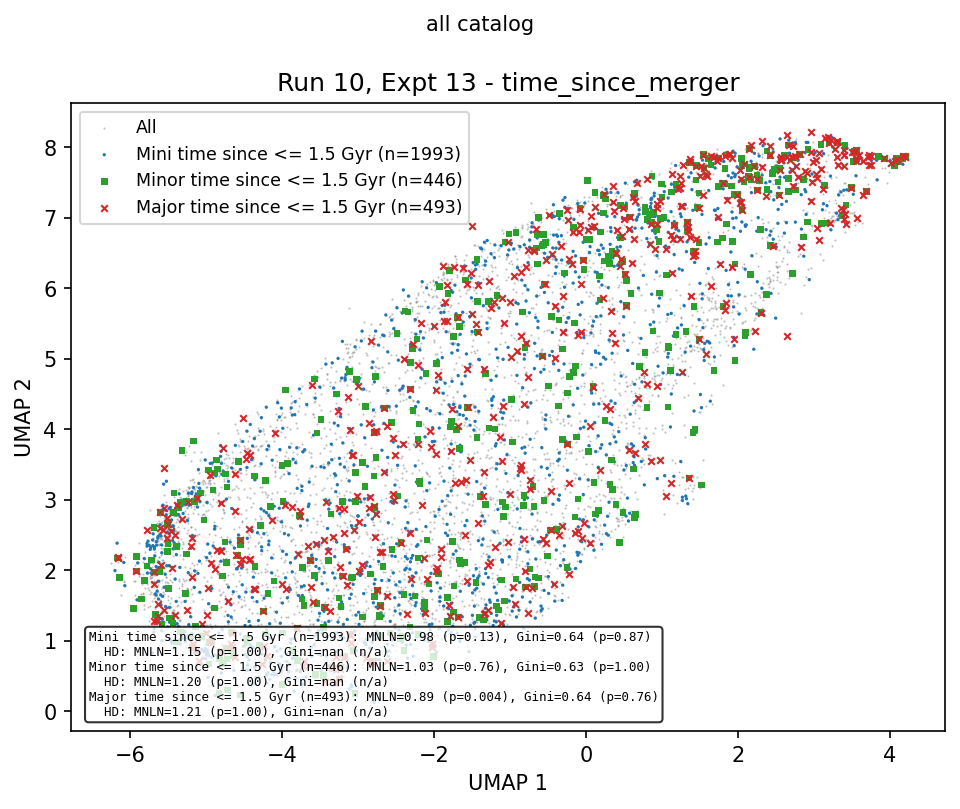

**hd | Run 10, Expt 14, cutoff 1 Gyr, Mini time since <= 1 Gyr**  \
2D MNLN p=0.005988, 2D ratio=0.936, HD MNLN p=1, HD ratio=1.155

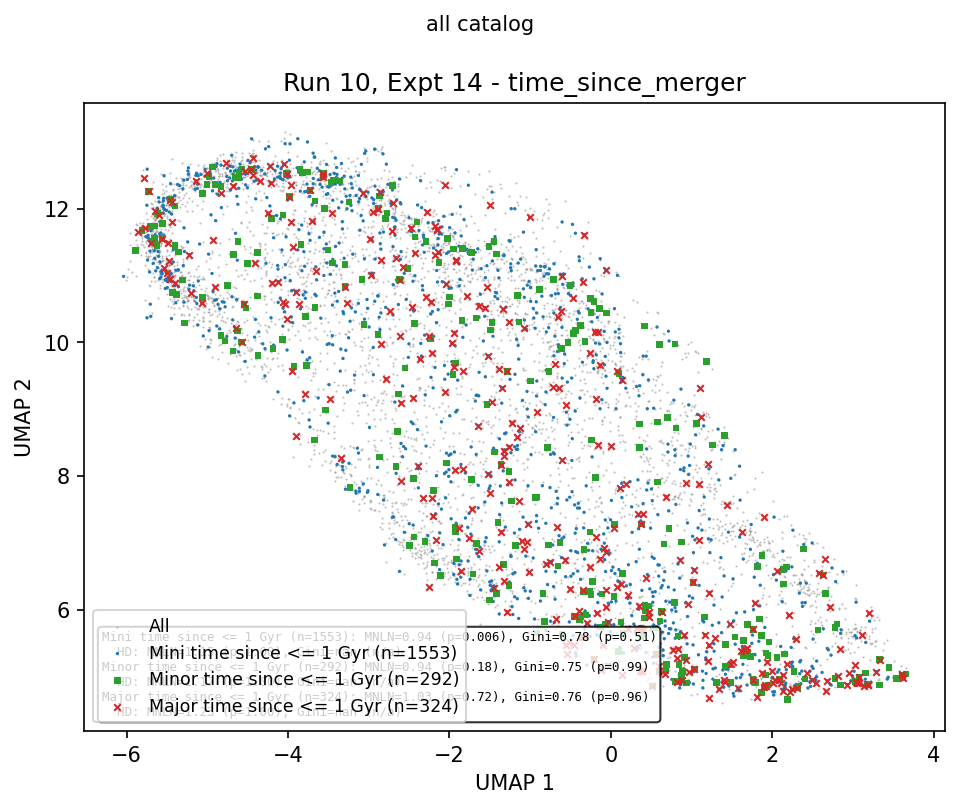

**hd | Run 10, Expt 5, cutoff 1.5 Gyr, Mini time since <= 1.5 Gyr**  \
2D MNLN p=0.8663, 2D ratio=1.028, HD MNLN p=1, HD ratio=1.159

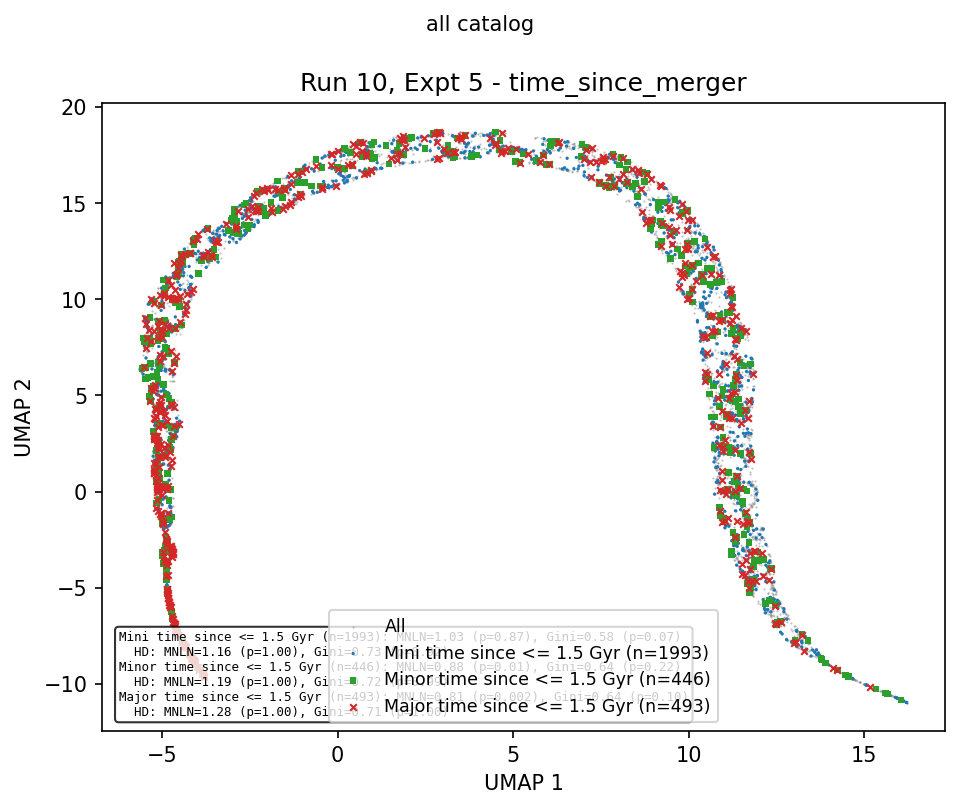

**hd | Run 10, Expt 13, cutoff 0.75 Gyr, Minor time since <= 0.75 Gyr**  \
2D MNLN p=0.007984, 2D ratio=0.8436, HD MNLN p=1, HD ratio=1.162

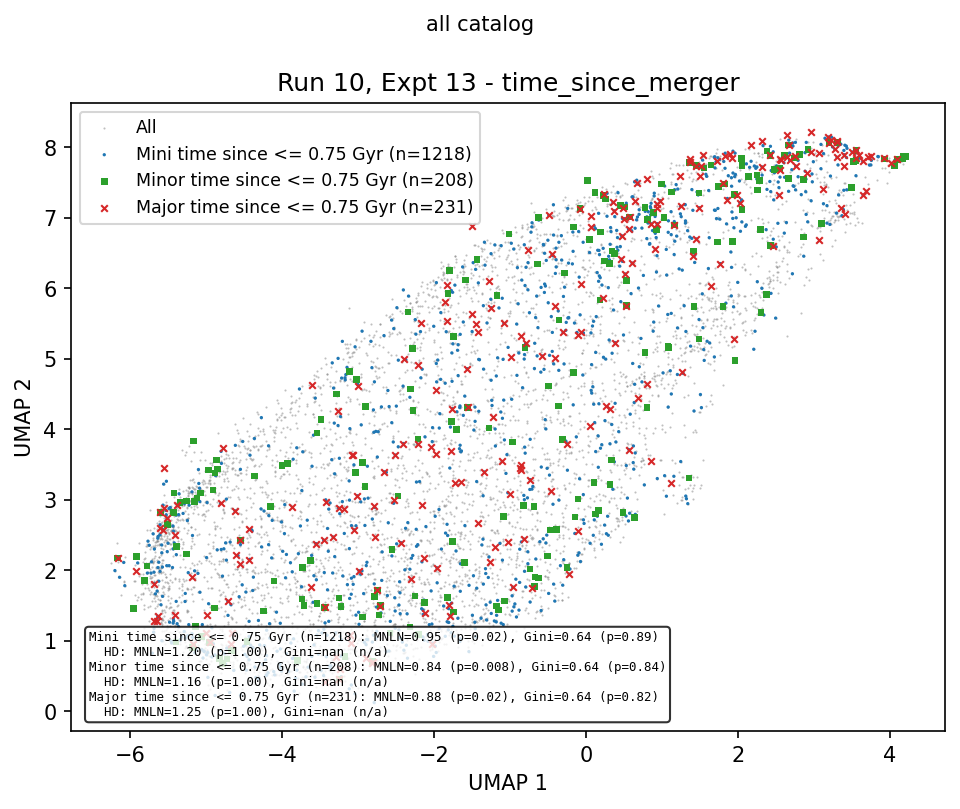

**hd | Run 10, Expt 13, cutoff 0.5 Gyr, Minor time since <= 0.5 Gyr**  \
2D MNLN p=0.001996, 2D ratio=0.781, HD MNLN p=1, HD ratio=1.164

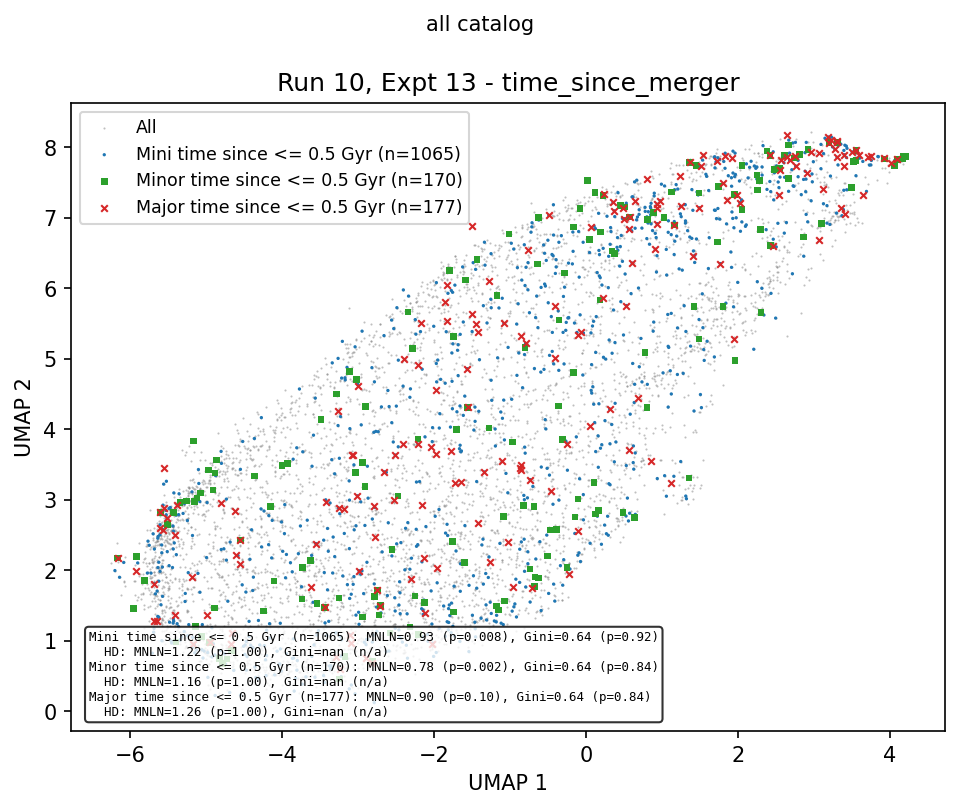

**hd | Run 10, Expt 14, cutoff 1 Gyr, Minor time since <= 1 Gyr**  \
2D MNLN p=0.1776, 2D ratio=0.9424, HD MNLN p=1, HD ratio=1.173

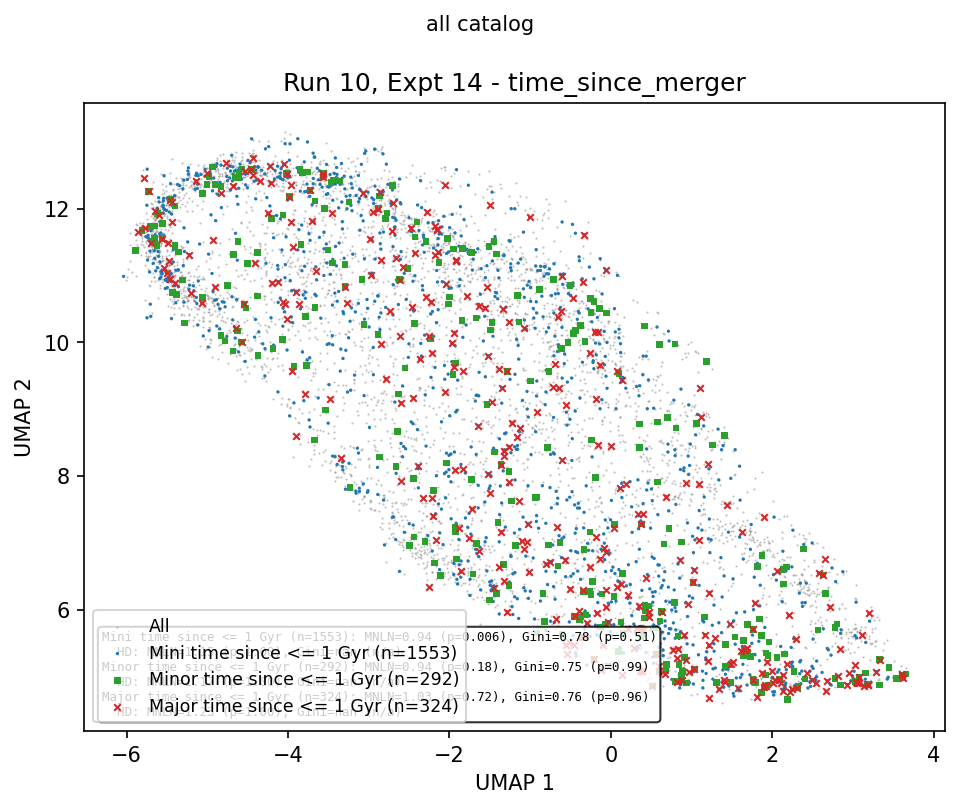

In [6]:
all_metric_results, ranked_metric_results = display_multicutoff_results()


In [7]:
all_metric_results[
    (all_metric_results["result_family"].eq("hd")) &
    (all_metric_results["mnln_hd_ratio"] < 1) &
    (all_metric_results["mnln_hd_p_value"] < 0.05)
].sort_values(["mnln_hd_p_value", "mnln_hd_ratio"])

,cmc_2d_cluster_counts,cmc_2d_expected_gini,cmc_2d_gini,cmc_2d_n_clusters,cmc_2d_n_labeled,cmc_2d_p_value,cmc_2d_std_null,cmc_2d_z_score,cmc_hd_cluster_counts,cmc_hd_expected_gini,cmc_hd_gini,cmc_hd_n_clusters,cmc_hd_n_labeled,cmc_hd_p_value,cmc_hd_std_null,cmc_hd_z_score,expt,mnln_2d_expected,mnln_2d_n_labeled,mnln_2d_observed,mnln_2d_p_value,mnln_2d_ratio,mnln_2d_std_null,mnln_2d_z_score,mnln_hd_expected,mnln_hd_n_labeled,mnln_hd_observed,mnln_hd_p_value,mnln_hd_ratio,mnln_hd_std_null,mnln_hd_z_score,n_matched,overlay_group,overlay_key,overlay_label,run,source_file,result_root,result_dir,result_family,cutoff_gyr,png_path,png_exists,has_highdim_metrics


In [ ]:
all_metric_results[
    (all_metric_results["result_family"].eq("hd")) &
    (all_metric_results["has_highdim_metrics"]) &
    (all_metric_results["cmc_hd_p_value"] < 0.05) &
    (all_metric_results["cmc_hd_z_score"] > 0)
].sort_values(["cmc_hd_p_value", "cmc_hd_z_score"], ascending=[True, False])

,cmc_2d_cluster_counts,cmc_2d_expected_gini,cmc_2d_gini,cmc_2d_n_clusters,cmc_2d_n_labeled,cmc_2d_p_value,cmc_2d_std_null,cmc_2d_z_score,cmc_hd_cluster_counts,cmc_hd_expected_gini,cmc_hd_gini,cmc_hd_n_clusters,cmc_hd_n_labeled,cmc_hd_p_value,cmc_hd_std_null,cmc_hd_z_score,expt,mnln_2d_expected,mnln_2d_n_labeled,mnln_2d_observed,mnln_2d_p_value,mnln_2d_ratio,mnln_2d_std_null,mnln_2d_z_score,mnln_hd_expected,mnln_hd_n_labeled,mnln_hd_observed,mnln_hd_p_value,mnln_hd_ratio,mnln_hd_std_null,mnln_hd_z_score,n_matched,overlay_group,overlay_key,overlay_label,run,source_file,result_root,result_dir,result_family,cutoff_gyr,png_path,png_exists,has_highdim_metrics
15,"{""-1"": 175, ""0"": 5, ""1"": 3, ""2"": 5, ""3"": 2, ""4"": 2, ""6"": 21, ""7"": 5, ""8"": 4, ""9"": 3, ""10"": 5, ""11"": 2, ""12"": 13, ""13"": 5, ""14"": 6, ""15"": 13, ""16"": 4, ""17"": 3, ""18"": 18, ""19"": 1, ""20"": 5, ""21"": 6, ""22"": 5, ""23"": 2, ""24"": 3, ""25"": 11, ""26"": 2, ""27"": 8, ""28"": 7, ""29"": 6, ""30"": 9, ""31"": 7, ""32"": 5, ""33"": 5, ""34"": 2, ""35"": 13, ""36"": 5, ""37"": 4, ""38"": 6, ""40"": 3, ""41"": 4, ""42"": 7, ""43"": 5, ""44"": 1, ""45"": 11, ""46"": 8, ""47"": 8, ""48"": 3, ""49"": 3, ""50"": 1, ""51"": 3, ""52"": 2, ""53"": 6, ""54"": 4, ""55"": 3, ""56"": 11, ""57"": 4, ""58"": 9, ""59"": 5, ""60"": 10, ""61"": 5, ""62"": 4, ""63"": 7, ""64"": 2, ""65"": 1, ""66"": 3, ""67"": 12, ""68"": 12, ""69"": 7, ""70"": 1, ""71"": 3, ""72"": 2, ""73"": 7, ""74"": 7, ""75"": 5, ""76"": 4, ""77"": 6, ""78"": 4, ""79"": 2, ""80"": 13, ""81"": 10, ""82"": 4, ""83"": 12, ""84"": 4, ""85"": 3, ""87"": 4, ""88"": 7, ""89"": 5, ""90"": 8, ""91"": 4, ""93"": 4, ""94"": 3, ""95"": 2, ""96"": 4, ""97"": 10, ""98"": 6, ""99"": 5, ""100"": 6, ""101"": 10, ""102"": 7, ""103"": 6, ""104"": 14, ""105"": 8, ""106"": 4, ""107"": 1, ""108"": 4, ""109"": 2, ""110"": 2, ""111"": 1, ""112"": 6, ""113"": 5, ""114"": 4, ""115"": 5, ""116"": 7, ""117"": 9, ""118"": 5, ""119"": 13, ""120"": 11, ""121"": 4, ""122"": 9, ""123"": 9, ""124"": 8, ""125"": 14, ""126"": 11, ""127"": 6, ""128"": 4, ""129"": 11, ""130"": 4, ""131"": 4, ""132"": 2, ""133"": 18, ""134"": 8, ""135"": 4, ""136"": 6, ""137"": 5, ""139"": 3, ""141"": 2, ""142"": 2, ""143"": 9, ""144"": 7, ""145"": 11, ""146"": 11, ""147"": 10, ""148"": 4, ""149"": 4, ""150"": 5, ""151"": 6, ""152"": 2, ""153"": 1, ""154"": 5, ""155"": 5, ""156"": 3, ""157"": 7, ""158"": 8, ""159"": 10, ""160"": 8, ""161"": 20, ""162"": 5, ""163"": 4, ""164"": 3, ""165"": 5, ""166"": 6, ""167"": 4, ""168"": 3, ""169"": 3, ""170"": 5, ""171"": 2, ""172"": 24, ""173"": 2, ""174"": 10, ""175"": 2, ""176"": 3, ""177"": 4, ""178"": 8, ""179"": 6}",0.392363,0.449256,180,1218,0.001996,0.014256,3.990800,"{""-1"": 267, ""0"": 2, ""1"": 17, ""2"": 6, ""3"": 7, ""4"": 17, ""5"": 12, ""6"": 12, ""7"": 5, ""8"": 4, ""9"": 13, ""10"": 39, ""11"": 21, ""12"": 7, ""13"": 17, ""14"": 64, ""15"": 9, ""16"": 20, ""17"": 4, ""18"": 11, ""19"": 16, ""20"": 23, ""21"": 7, ""22"": 12, ""23"": 5, ""24"": 15, ""25"": 6, ""26"": 9, ""27"": 18, ""28"": 8, ""29"": 3, ""30"": 10, ""31"": 10, ""32"": 9, ""33"": 12, ""34"": 8, ""35"": 24, ""36"": 22, ""37"": 2, ""38"": 4, ""39"": 11, ""40"": 5, ""41"": 2, ""42"": 5, ""43"": 3, ""44"": 9, ""45"": 8, ""46"": 13, ""47"": 6, ""48"": 12, ""49"": 14, ""50"": 11, ""51"": 10, ""52"": 3, ""53"": 3, ""54"": 13, ""55"": 8, ""56"": 15, ""57"": 5, ""58"": 8, ""59"": 8, ""60"": 3, ""61"": 5, ""62"": 5, ""63"": 26, ""64"": 9, ""65"": 26, ""66"": 35, ""67"": 11, ""68"": 20, ""69"": 6, ""70"": 2, ""71"": 11, ""72"": 3, ""73"": 4, ""74"": 3, ""75"": 5, ""76"": 3, ""77"": 3, ""78"": 2, ""79"": 6, ""80"": 3, ""81"": 8, ""82"": 2, ""83"": 4, ""84"": 8, ""85"": 3, ""86"": 2, ""87"": 7, ""88"": 4, ""89"": 13, ""90"": 4, ""91"": 4, ""92"": 2, ""93"": 5, ""94"": 3, ""95"": 8, ""96"": 1}",0.506212,0.537817,97,1218,0.005988,0.014051,2.249312,6,0.030477,1218,0.025295,0.005988,0.829963,0.001713,-3.025021,2.378347e+06,1218,3.238650e+

In [9]:
all_metric_results[
    (all_metric_results["result_family"].eq("hd")) &
    (all_metric_results["has_highdim_metrics"]) &
    (all_metric_results["cmc_hd_p_value"] < 0.05) &
    (all_metric_results["cmc_hd_z_score"] > 0)
].sort_values(["cmc_hd_p_value", "cmc_hd_z_score"], ascending=[True, False])

,cmc_2d_cluster_counts,cmc_2d_expected_gini,cmc_2d_gini,cmc_2d_n_clusters,cmc_2d_n_labeled,cmc_2d_p_value,cmc_2d_std_null,cmc_2d_z_score,cmc_hd_cluster_counts,cmc_hd_expected_gini,cmc_hd_gini,cmc_hd_n_clusters,cmc_hd_n_labeled,cmc_hd_p_value,cmc_hd_std_null,cmc_hd_z_score,expt,mnln_2d_expected,mnln_2d_n_labeled,mnln_2d_observed,mnln_2d_p_value,mnln_2d_ratio,mnln_2d_std_null,mnln_2d_z_score,mnln_hd_expected,mnln_hd_n_labeled,mnln_hd_observed,mnln_hd_p_value,mnln_hd_ratio,mnln_hd_std_null,mnln_hd_z_score,n_matched,overlay_group,overlay_key,overlay_label,run,source_file,result_root,result_dir,result_family,cutoff_gyr,png_path,png_exists,has_highdim_metrics
15,"{""-1"": 175, ""0"": 5, ""1"": 3, ""2"": 5, ""3"": 2, ""4"": 2, ""6"": 21, ""7"": 5, ""8"": 4, ""9"": 3, ""10"": 5, ""11"": 2, ""12"": 13, ""13"": 5, ""14"": 6, ""15"": 13, ""16"": 4, ""17"": 3, ""18"": 18, ""19"": 1, ""20"": 5, ""21"": 6, ""22"": 5, ""23"": 2, ""24"": 3, ""25"": 11, ""26"": 2, ""27"": 8, ""28"": 7, ""29"": 6, ""30"": 9, ""31"": 7, ""32"": 5, ""33"": 5, ""34"": 2, ""35"": 13, ""36"": 5, ""37"": 4, ""38"": 6, ""40"": 3, ""41"": 4, ""42"": 7, ""43"": 5, ""44"": 1, ""45"": 11, ""46"": 8, ""47"": 8, ""48"": 3, ""49"": 3, ""50"": 1, ""51"": 3, ""52"": 2, ""53"": 6, ""54"": 4, ""55"": 3, ""56"": 11, ""57"": 4, ""58"": 9, ""59"": 5, ""60"": 10, ""61"": 5, ""62"": 4, ""63"": 7, ""64"": 2, ""65"": 1, ""66"": 3, ""67"": 12, ""68"": 12, ""69"": 7, ""70"": 1, ""71"": 3, ""72"": 2, ""73"": 7, ""74"": 7, ""75"": 5, ""76"": 4, ""77"": 6, ""78"": 4, ""79"": 2, ""80"": 13, ""81"": 10, ""82"": 4, ""83"": 12, ""84"": 4, ""85"": 3, ""87"": 4, ""88"": 7, ""89"": 5, ""90"": 8, ""91"": 4, ""93"": 4, ""94"": 3, ""95"": 2, ""96"": 4, ""97"": 10, ""98"": 6, ""99"": 5, ""100"": 6, ""101"": 10, ""102"": 7, ""103"": 6, ""104"": 14, ""105"": 8, ""106"": 4, ""107"": 1, ""108"": 4, ""109"": 2, ""110"": 2, ""111"": 1, ""112"": 6, ""113"": 5, ""114"": 4, ""115"": 5, ""116"": 7, ""117"": 9, ""118"": 5, ""119"": 13, ""120"": 11, ""121"": 4, ""122"": 9, ""123"": 9, ""124"": 8, ""125"": 14, ""126"": 11, ""127"": 6, ""128"": 4, ""129"": 11, ""130"": 4, ""131"": 4, ""132"": 2, ""133"": 18, ""134"": 8, ""135"": 4, ""136"": 6, ""137"": 5, ""139"": 3, ""141"": 2, ""142"": 2, ""143"": 9, ""144"": 7, ""145"": 11, ""146"": 11, ""147"": 10, ""148"": 4, ""149"": 4, ""150"": 5, ""151"": 6, ""152"": 2, ""153"": 1, ""154"": 5, ""155"": 5, ""156"": 3, ""157"": 7, ""158"": 8, ""159"": 10, ""160"": 8, ""161"": 20, ""162"": 5, ""163"": 4, ""164"": 3, ""165"": 5, ""166"": 6, ""167"": 4, ""168"": 3, ""169"": 3, ""170"": 5, ""171"": 2, ""172"": 24, ""173"": 2, ""174"": 10, ""175"": 2, ""176"": 3, ""177"": 4, ""178"": 8, ""179"": 6}",0.392363,0.449256,180,1218,0.001996,0.014256,3.990800,"{""-1"": 267, ""0"": 2, ""1"": 17, ""2"": 6, ""3"": 7, ""4"": 17, ""5"": 12, ""6"": 12, ""7"": 5, ""8"": 4, ""9"": 13, ""10"": 39, ""11"": 21, ""12"": 7, ""13"": 17, ""14"": 64, ""15"": 9, ""16"": 20, ""17"": 4, ""18"": 11, ""19"": 16, ""20"": 23, ""21"": 7, ""22"": 12, ""23"": 5, ""24"": 15, ""25"": 6, ""26"": 9, ""27"": 18, ""28"": 8, ""29"": 3, ""30"": 10, ""31"": 10, ""32"": 9, ""33"": 12, ""34"": 8, ""35"": 24, ""36"": 22, ""37"": 2, ""38"": 4, ""39"": 11, ""40"": 5, ""41"": 2, ""42"": 5, ""43"": 3, ""44"": 9, ""45"": 8, ""46"": 13, ""47"": 6, ""48"": 12, ""49"": 14, ""50"": 11, ""51"": 10, ""52"": 3, ""53"": 3, ""54"": 13, ""55"": 8, ""56"": 15, ""57"": 5, ""58"": 8, ""59"": 8, ""60"": 3, ""61"": 5, ""62"": 5, ""63"": 26, ""64"": 9, ""65"": 26, ""66"": 35, ""67"": 11, ""68"": 20, ""69"": 6, ""70"": 2, ""71"": 11, ""72"": 3, ""73"": 4, ""74"": 3, ""75"": 5, ""76"": 3, ""77"": 3, ""78"": 2, ""79"": 6, ""80"": 3, ""81"": 8, ""82"": 2, ""83"": 4, ""84"": 8, ""85"": 3, ""86"": 2, ""87"": 7, ""88"": 4, ""89"": 13, ""90"": 4, ""91"": 4, ""92"": 2, ""93"": 5, ""94"": 3, ""95"": 8, ""96"": 1}",0.506212,0.537817,97,1218,0.005988,0.014051,2.249312,6,0.030477,1218,0.025295,0.005988,0.829963,0.001713,-3.025021,2.378347e+06,1218,3.238650e+

## Generate high-dimensional jobs

Run the 2D results viewer first if `HD_MODE = "top_2d"`; it uses `ranked_metric_results` to choose the top run/expt/cutoff combinations and writes HD jobs into separate `_hd` result folders. Set `HD_MODE = "full_sweep"` to generate HD jobs for every configured cutoff and `HD_RUN_EXPTS` entry.

`SKIP_COMPLETED_HD = True` prevents rerunning jobs whose `_hd` metrics CSV already contains real HD metric columns. Missing or incomplete HD outputs are kept in the plan. Set `HD_FORCE_RERUN = True` only when you intentionally want to regenerate completed HD outputs.


In [70]:
HD_MODE = "top_2d"      # "top_2d" or "full_sweep"
HD_TOP_N = 20
HD_CUTOFFS = RESULT_CUTOFFS
HD_RUN_EXPTS = None       # None uses RUN_EXPTS for full_sweep. Example: ["10:1-18"]
HD_OVERLAY_GROUPS = OVERLAY_GROUPS
HD_REQUIRE_HIGHDIM = True
HD_SUBMIT_JOBS = True
SKIP_COMPLETED_HD = True
HD_FORCE_RERUN = False
SHOW_HD_COMPLETION_TABLE = True
MAX_HD_COMPLETION_TABLE_ROWS = 100
HD_REQUIRED_COLUMNS_FOR_SKIP = HD_REQUIRED_RESULT_COLUMNS

HD_OUTPUT_SUFFIX = "_hd"
HD_JOB_PREFIX_TEMPLATE = "plot_metrics_hd_tsm_{cutoff_label}_"
HD_SLURM_OVERRIDES = {"mem": "100G", "time": "8:00:00"}


def cutoff_label(cutoff):
    cutoff = float(cutoff)
    text = f"{cutoff:.1f}" if cutoff.is_integer() else f"{cutoff:g}"
    return text.replace(".", "p")


def hd_output_dir(cutoff):
    return BASE_DIR / f"static_umap_metrics_tsm_le_{cutoff_label(cutoff)}gyr{HD_OUTPUT_SUFFIX}"


def hd_job_prefix(cutoff):
    return HD_JOB_PREFIX_TEMPLATE.format(cutoff_label=cutoff_label(cutoff))


def run_expt_spec(run, expts):
    expt_text = ",".join(str(int(expt)) for expt in sorted(set(expts)))
    return f"{int(run)}:{expt_text}"


def parse_hd_number_spec(spec):
    if not isinstance(spec, str):
        return sorted({int(number) for number in spec})
    values = set()
    for raw_part in spec.split(","):
        part = raw_part.strip()
        if not part:
            continue
        if "-" in part:
            start, end = part.split("-", 1)
            values.update(range(int(start), int(end) + 1))
        else:
            values.add(int(part))
    return sorted(values)


def parse_hd_run_expt_specs(specs):
    parsed = {}
    for spec in specs:
        if ":" in spec:
            run_text, expts_text = spec.split(":", 1)
        elif "=" in spec:
            run_text, expts_text = spec.split("=", 1)
        else:
            raise ValueError(f"HD run spec '{spec}' must look like RUN:EXPTS, for example 10:7,10,12")
        run = int(run_text.strip())
        parsed.setdefault(run, set()).update(parse_hd_number_spec(expts_text))
    return {run: sorted(expts) for run, expts in sorted(parsed.items())}


def hd_jobs_from_plan(plan):
    rows = []
    for cutoff, specs in sorted(plan.items()):
        if not specs:
            raise ValueError("HD duplicate protection needs explicit run/expt specs; generator defaults cannot be checked safely.")
        for run, expts in parse_hd_run_expt_specs(specs).items():
            for expt in expts:
                rows.append({"cutoff_gyr": float(cutoff), "run": int(run), "expt": int(expt)})
    return pd.DataFrame(rows).drop_duplicates().sort_values(["cutoff_gyr", "run", "expt"]).reset_index(drop=True)


def hd_metrics_csv_path(cutoff, run, expt):
    return hd_output_dir(cutoff) / f"run{int(run)}" / f"expt{int(expt)}" / f"run{int(run)}_expt{int(expt)}_metrics.csv"


def classify_hd_job(cutoff, run, expt):
    metrics_csv = hd_metrics_csv_path(cutoff, run, expt)
    base = {"metrics_csv": str(metrics_csv)}
    if not metrics_csv.exists():
        return {**base, "status": "missing", "reason": "metrics CSV does not exist"}

    try:
        metrics = pd.read_csv(metrics_csv)
    except Exception as exc:
        return {**base, "status": "incomplete", "reason": f"could not read metrics CSV: {exc}"}

    if metrics.empty:
        return {**base, "status": "incomplete", "reason": "metrics CSV has no rows"}

    required_columns = list(HD_REQUIRED_COLUMNS_FOR_SKIP)
    missing_columns = [column for column in required_columns if column not in metrics.columns]
    if missing_columns:
        return {**base, "status": "incomplete", "reason": f"missing HD columns: {missing_columns}"}

    numeric_hd = metrics[required_columns].apply(pd.to_numeric, errors="coerce")
    if not numeric_hd.notna().all(axis=1).any():
        return {**base, "status": "incomplete", "reason": "HD columns exist but no row has complete HD values"}

    expected_groups = [str(group) for group in (HD_OVERLAY_GROUPS or [])]
    if expected_groups:
        if "overlay_group" not in metrics.columns:
            return {**base, "status": "incomplete", "reason": "metrics CSV does not record overlay_group"}
        found_groups = set(metrics["overlay_group"].dropna().astype(str))
        missing_groups = [group for group in expected_groups if group not in found_groups]
        if missing_groups:
            return {**base, "status": "incomplete", "reason": f"missing overlay groups: {missing_groups}"}

    return {**base, "status": "complete", "reason": "HD metrics found"}


def regroup_hd_jobs(rows):
    if rows.empty:
        return {}
    plan = {}
    for _, row in rows.iterrows():
        cutoff = float(row["cutoff_gyr"])
        run = int(row["run"])
        expt = int(row["expt"])
        plan.setdefault(cutoff, {}).setdefault(run, set()).add(expt)
    return {
        cutoff: [run_expt_spec(run, expts) for run, expts in sorted(run_map.items())]
        for cutoff, run_map in sorted(plan.items())
    }


def filter_completed_hd_plan(plan):
    jobs = hd_jobs_from_plan(plan)
    if jobs.empty:
        return plan, pd.DataFrame()

    status_rows = []
    for _, row in jobs.iterrows():
        job = {"cutoff_gyr": float(row["cutoff_gyr"]), "run": int(row["run"]), "expt": int(row["expt"])}
        status_rows.append({**job, **classify_hd_job(job["cutoff_gyr"], job["run"], job["expt"])})
    report = pd.DataFrame(status_rows)

    skip_enabled = bool(SKIP_COMPLETED_HD) and not bool(HD_FORCE_RERUN)
    report["will_run"] = True
    if skip_enabled:
        report.loc[report["status"].eq("complete"), "will_run"] = False

    counts = report["status"].value_counts().to_dict()
    skipped = int((~report["will_run"]).sum())
    print(f"HD duplicate protection: {'enabled' if skip_enabled else 'disabled'}")
    if HD_FORCE_RERUN:
        print("HD_FORCE_RERUN is True; completed HD outputs will be regenerated.")
    print(
        "HD job status: "
        f"complete={counts.get('complete', 0)}, "
        f"incomplete={counts.get('incomplete', 0)}, "
        f"missing={counts.get('missing', 0)}, "
        f"skipped={skipped}, "
        f"will_run={int(report['will_run'].sum())}"
    )

    if SHOW_HD_COMPLETION_TABLE:
        display_cols = ["cutoff_gyr", "run", "expt", "status", "will_run", "reason", "metrics_csv"]
        display(report[display_cols].head(int(MAX_HD_COMPLETION_TABLE_ROWS)))

    filtered_jobs = report[report["will_run"]][["cutoff_gyr", "run", "expt"]]
    return regroup_hd_jobs(filtered_jobs), report


def top_2d_run_expts_by_cutoff(ranked, top_n=HD_TOP_N):
    if ranked is None or ranked.empty:
        raise ValueError("No ranked 2D results found. Run `all_metric_results, ranked_metric_results = display_multicutoff_results()` first, or set HD_MODE='full_sweep'.")
    work = ranked.copy()
    if "rank" in work.columns:
        work = work.sort_values("rank")
    if "result_family" in work.columns:
        work = work[work["result_family"].fillna("2d").eq("2d")]
    if "cutoff_gyr" in work.columns:
        work["_hd_cutoff_gyr"] = work["cutoff_gyr"]
    else:
        work["_hd_cutoff_gyr"] = pd.NA
    if "best_cutoff_gyr" in work.columns:
        work["_hd_cutoff_gyr"] = work["_hd_cutoff_gyr"].fillna(work["best_cutoff_gyr"])
    work = work.dropna(subset=["run", "expt", "_hd_cutoff_gyr"])
    work = work.head(int(top_n))
    if work.empty:
        raise ValueError("The top-ranked table did not contain any 2D run/expt/cutoff rows for HD targeting.")

    plan = {}
    for _, row in work.iterrows():
        cutoff = float(row["_hd_cutoff_gyr"])
        run = int(row["run"])
        expt = int(row["expt"])
        plan.setdefault(cutoff, {}).setdefault(run, set()).add(expt)
    return {
        cutoff: [run_expt_spec(run, expts) for run, expts in sorted(run_map.items())]
        for cutoff, run_map in sorted(plan.items())
    }


def full_sweep_run_expts_by_cutoff():
    run_expts = RUN_EXPTS if HD_RUN_EXPTS is None else HD_RUN_EXPTS
    return {float(cutoff): list(run_expts) for cutoff in HD_CUTOFFS}


def resolve_hd_run_expts_by_cutoff():
    if HD_MODE == "top_2d":
        return top_2d_run_expts_by_cutoff(globals().get("ranked_metric_results"), top_n=HD_TOP_N)
    if HD_MODE == "full_sweep":
        return full_sweep_run_expts_by_cutoff()
    raise ValueError("HD_MODE must be 'top_2d' or 'full_sweep'")


def build_hd_generator_command(action, cutoff, run_expts, *, dry_run=False):
    slurm_overrides = {**SLURM_OVERRIDES, **HD_SLURM_OVERRIDES}
    cmd = [
        GENERATOR_PYTHON,
        GENERATOR,
        action,
        "--profile",
        PROFILE,
        "--base-directory",
        BASE_DIR,
        "--output-dir",
        hd_output_dir(cutoff),
        "--analysis-script",
        ANALYSIS_SCRIPT,
        "--python-executable",
        JOB_PYTHON,
        "--job-prefix",
        hd_job_prefix(cutoff),
        "--catalog-key",
        CATALOG_KEY,
        "--n-permutations",
        N_PERMUTATIONS,
        "--min-cluster-size",
        MIN_CLUSTER_SIZE,
        "--seed",
        SEED,
        "--dpi",
        DPI,
        "--time-since-merger-max-gyr",
        cutoff,
        "--include-highdim",
    ]
    if HD_REQUIRE_HIGHDIM:
        cmd.append("--require-highdim")
    for spec in run_expts:
        cmd.extend(["--run-expts", spec])
    for group in HD_OVERLAY_GROUPS:
        cmd.extend(["--overlay-group", group])
    for key, value in slurm_overrides.items():
        cmd.extend(["--slurm", f"{key}={value}"])
    if DENSITY:
        cmd.append("--density")
    if LOG_COLORBAR:
        cmd.append("--log-colorbar")
    if not SHOW_LEGEND:
        cmd.append("--no-show-legend")
    if not SUPPRESS_LOGS:
        cmd.append("--no-suppress-logs")
    if SETUP_LINES is not None:
        if len(SETUP_LINES) == 0:
            cmd.append("--no-default-setup")
        else:
            for line in SETUP_LINES:
                cmd.extend(["--setup-line", line])
    elif NO_DEFAULT_SETUP:
        cmd.append("--no-default-setup")
    if dry_run:
        cmd.append("--dry-run")
    return cmd


def build_hd_generator_commands(action, *, dry_run=False):
    commands = []
    raw_plan = resolve_hd_run_expts_by_cutoff()
    plan, report = filter_completed_hd_plan(raw_plan)
    globals()["hd_completion_report"] = report
    print(f"HD mode: {HD_MODE}")
    if not plan:
        print("No HD jobs remain after duplicate protection filtering.")
        return commands
    for cutoff, run_expts in plan.items():
        print(f"cutoff={cutoff:g} Gyr | output={hd_output_dir(cutoff)} | prefix={hd_job_prefix(cutoff)} | run_expts={run_expts or '[generator defaults]'}")
        commands.append(build_hd_generator_command(action, cutoff, run_expts, dry_run=dry_run))
    return commands


def run_hd_generator_commands(action, *, dry_run=False, check=True):
    results = []
    for cmd in build_hd_generator_commands(action, dry_run=dry_run):
        results.append(run_command(cmd, check=check))
    return results


### Preview HD plan

This prints the generator plan for each targeted cutoff without writing scripts.


In [66]:
run_hd_generator_commands("print-plan")


HD duplicate protection: enabled
HD job status: complete=0, incomplete=0, missing=18, skipped=0, will_run=18


,cutoff_gyr,run,expt,status,will_run,reason,metrics_csv
0,0.50,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt6/run10_expt6_metrics.csv
1,0.50,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt8/run10_expt8_metrics.csv
2,0.50,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt13/run10_expt13_metrics.csv
3,0.75,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt6/run10_expt6_metrics.csv
4,0.75,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt7/run10_expt7_metrics.csv
5,0.75,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt13/run10_expt13_metrics.csv
6,0.75,10,16,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt16/run10_expt16_metrics.csv
7,1.00,10,5,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt5/run10_expt5_metrics.csv
8,1.00,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt7/run10_expt7_metrics.csv
9,1.00,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt8/run10_expt8_metrics.csv


HD mode: top_2d
cutoff=0.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd | prefix=plot_metrics_hd_tsm_0p5_ | run_expts=['10:6,8,13']
cutoff=0.75 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd | prefix=plot_metrics_hd_tsm_0p75_ | run_expts=['10:6,7,13,16']
cutoff=1 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd | prefix=plot_metrics_hd_tsm_1p0_ | run_expts=['10:5,7,8,14']
cutoff=1.25 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p25gyr_hd | prefix=plot_metrics_hd_tsm_1p25_ | run_expts=['10:5,8,10']
cutoff=1.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd | prefix=plot_metrics_hd_tsm_1p5_ | run_expts=['10:5,8,11,13']
$ python /work/hdd/bemi/dmiura/Hyrax-Research/static_umap

[CompletedProcess(args=['python', '/work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metric_job_generator.py', 'print-plan', '--profile', 'delta', '--base-directory', '/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs', '--output-dir', '/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd', '--analysis-script', '/work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metrics.py', '--python-executable', 'python', '--job-prefix', 'plot_metrics_hd_tsm_0p5_', '--catalog-key', 'all', '--n-permutations', '500', '--min-cluster-size', '15', '--seed', '42', '--dpi', '150', '--time-since-merger-max-gyr', '0.5', '--include-highdim', '--require-highdim', '--run-expts', '10:6,8,13', '--overlay-group', 'time_since_merger', '--slurm', 'mem=100G', '--slurm', 'time=8:00:00'], returncode=0, stdout="Analysis script: /work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metrics.py\nBase directory: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs\nO

### Generate HD Slurm scripts

This writes HD scripts with separate output directories and job prefixes.


In [67]:
run_hd_generator_commands("write")


HD duplicate protection: enabled
HD job status: complete=0, incomplete=0, missing=18, skipped=0, will_run=18


,cutoff_gyr,run,expt,status,will_run,reason,metrics_csv
0,0.50,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt6/run10_expt6_metrics.csv
1,0.50,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt8/run10_expt8_metrics.csv
2,0.50,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt13/run10_expt13_metrics.csv
3,0.75,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt6/run10_expt6_metrics.csv
4,0.75,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt7/run10_expt7_metrics.csv
5,0.75,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt13/run10_expt13_metrics.csv
6,0.75,10,16,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt16/run10_expt16_metrics.csv
7,1.00,10,5,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt5/run10_expt5_metrics.csv
8,1.00,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt7/run10_expt7_metrics.csv
9,1.00,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt8/run10_expt8_metrics.csv


HD mode: top_2d
cutoff=0.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd | prefix=plot_metrics_hd_tsm_0p5_ | run_expts=['10:6,8,13']
cutoff=0.75 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd | prefix=plot_metrics_hd_tsm_0p75_ | run_expts=['10:6,7,13,16']
cutoff=1 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd | prefix=plot_metrics_hd_tsm_1p0_ | run_expts=['10:5,7,8,14']
cutoff=1.25 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p25gyr_hd | prefix=plot_metrics_hd_tsm_1p25_ | run_expts=['10:5,8,10']
cutoff=1.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd | prefix=plot_metrics_hd_tsm_1p5_ | run_expts=['10:5,8,11,13']
$ python /work/hdd/bemi/dmiura/Hyrax-Research/static_umap

[CompletedProcess(args=['python', '/work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metric_job_generator.py', 'write', '--profile', 'delta', '--base-directory', '/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs', '--output-dir', '/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd', '--analysis-script', '/work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metrics.py', '--python-executable', 'python', '--job-prefix', 'plot_metrics_hd_tsm_0p5_', '--catalog-key', 'all', '--n-permutations', '500', '--min-cluster-size', '15', '--seed', '42', '--dpi', '150', '--time-since-merger-max-gyr', '0.5', '--include-highdim', '--require-highdim', '--run-expts', '10:6,8,13', '--overlay-group', 'time_since_merger', '--slurm', 'mem=100G', '--slurm', 'time=8:00:00'], returncode=0, stdout='Created /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/run10/plot_metrics_hd_tsm_0p5_10_6.sh\nCreated /work/hdd/bemi/dmiura/data_downloads/tng100_sn

### Dry-run HD submission

This prints the `sbatch` commands for already-generated HD scripts.


In [68]:
run_hd_generator_commands("submit-existing", dry_run=True)


HD duplicate protection: enabled
HD job status: complete=0, incomplete=0, missing=18, skipped=0, will_run=18


,cutoff_gyr,run,expt,status,will_run,reason,metrics_csv
0,0.50,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt6/run10_expt6_metrics.csv
1,0.50,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt8/run10_expt8_metrics.csv
2,0.50,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt13/run10_expt13_metrics.csv
3,0.75,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt6/run10_expt6_metrics.csv
4,0.75,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt7/run10_expt7_metrics.csv
5,0.75,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt13/run10_expt13_metrics.csv
6,0.75,10,16,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt16/run10_expt16_metrics.csv
7,1.00,10,5,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt5/run10_expt5_metrics.csv
8,1.00,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt7/run10_expt7_metrics.csv
9,1.00,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt8/run10_expt8_metrics.csv


HD mode: top_2d
cutoff=0.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd | prefix=plot_metrics_hd_tsm_0p5_ | run_expts=['10:6,8,13']
cutoff=0.75 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd | prefix=plot_metrics_hd_tsm_0p75_ | run_expts=['10:6,7,13,16']
cutoff=1 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd | prefix=plot_metrics_hd_tsm_1p0_ | run_expts=['10:5,7,8,14']
cutoff=1.25 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p25gyr_hd | prefix=plot_metrics_hd_tsm_1p25_ | run_expts=['10:5,8,10']
cutoff=1.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd | prefix=plot_metrics_hd_tsm_1p5_ | run_expts=['10:5,8,11,13']
$ python /work/hdd/bemi/dmiura/Hyrax-Research/static_umap

[CompletedProcess(args=['python', '/work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metric_job_generator.py', 'submit-existing', '--profile', 'delta', '--base-directory', '/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs', '--output-dir', '/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd', '--analysis-script', '/work/hdd/bemi/dmiura/Hyrax-Research/static_umap_metrics.py', '--python-executable', 'python', '--job-prefix', 'plot_metrics_hd_tsm_0p5_', '--catalog-key', 'all', '--n-permutations', '500', '--min-cluster-size', '15', '--seed', '42', '--dpi', '150', '--time-since-merger-max-gyr', '0.5', '--include-highdim', '--require-highdim', '--run-expts', '10:6,8,13', '--overlay-group', 'time_since_merger', '--slurm', 'mem=100G', '--slurm', 'time=8:00:00', '--dry-run'], returncode=0, stdout='Submitting from /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/run10: sbatch plot_metrics_hd_tsm_0p5_10_6.sh\nSubmitting from

### Submit HD jobs

Real submission is guarded by `HD_SUBMIT_JOBS`.


In [71]:
if HD_SUBMIT_JOBS:
    run_hd_generator_commands("submit-existing")
else:
    print("HD_SUBMIT_JOBS is False; not submitting.")


HD duplicate protection: enabled
HD job status: complete=0, incomplete=0, missing=18, skipped=0, will_run=18


,cutoff_gyr,run,expt,status,will_run,reason,metrics_csv
0,0.50,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt6/run10_expt6_metrics.csv
1,0.50,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt8/run10_expt8_metrics.csv
2,0.50,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd/run10/expt13/run10_expt13_metrics.csv
3,0.75,10,6,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt6/run10_expt6_metrics.csv
4,0.75,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt7/run10_expt7_metrics.csv
5,0.75,10,13,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt13/run10_expt13_metrics.csv
6,0.75,10,16,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd/run10/expt16/run10_expt16_metrics.csv
7,1.00,10,5,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt5/run10_expt5_metrics.csv
8,1.00,10,7,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt7/run10_expt7_metrics.csv
9,1.00,10,8,missing,True,metrics CSV does not exist,/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd/run10/expt8/run10_expt8_metrics.csv


HD mode: top_2d
cutoff=0.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p5gyr_hd | prefix=plot_metrics_hd_tsm_0p5_ | run_expts=['10:6,8,13']
cutoff=0.75 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_0p75gyr_hd | prefix=plot_metrics_hd_tsm_0p75_ | run_expts=['10:6,7,13,16']
cutoff=1 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p0gyr_hd | prefix=plot_metrics_hd_tsm_1p0_ | run_expts=['10:5,7,8,14']
cutoff=1.25 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p25gyr_hd | prefix=plot_metrics_hd_tsm_1p25_ | run_expts=['10:5,8,10']
cutoff=1.5 Gyr | output=/work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/static_umap_metrics_tsm_le_1p5gyr_hd | prefix=plot_metrics_hd_tsm_1p5_ | run_expts=['10:5,8,11,13']
$ python /work/hdd/bemi/dmiura/Hyrax-Research/static_umap